<a href="https://colab.research.google.com/github/wcaul10/Machine-Learning-Coursework-2/blob/main/Task-1-CW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import os
from google.colab import drive

# connecting google drive to allow checkpints
drive.mount('/content/drive')
checkpoint_dir = '/content/drive/MyDrive/ML_Coursework_Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'simclr_resnet18_checkpoint.pth')

# defining simclr augmentations
class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

color_jitter = transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                        transform=SimCLRTransform(train_transform))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=2, drop_last=True)

# defining untrained resnet-18 model
class SimCLR_ResNet18(nn.Module):
    def __init__(self, out_dim=128):
        super(SimCLR_ResNet18, self).__init__()
        # Loading baseline ResNet18 with no pre-trained weights
        self.backbone = torchvision.models.resnet18(weights=None)

        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.projection_head = nn.Sequential(
            nn.Linear(num_ftrs, num_ftrs),
            nn.ReLU(),
            nn.Linear(num_ftrs, out_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        projections = self.projection_head(features)
        return features, projections # getting features for K-means later

# simclr contrastive loss
def nt_xent_loss(proj1, proj2, temperature=0.5):
    batch_size = proj1.size(0)
    projections = torch.cat([proj1, proj2], dim=0)
    projections = F.normalize(projections, dim=1)

    # cosine similarity matrix
    similarity_matrix = torch.matmul(projections, projections.T)

    labels = torch.cat([torch.arange(batch_size) for i in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    labels = labels.to(proj1.device)

    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(proj1.device)
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)

    similarity_matrix = similarity_matrix / temperature

    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)
    logits = torch.cat([positives, negatives], dim=1)

    true_labels = torch.zeros(logits.shape[0], dtype=torch.long).to(proj1.device)
    return F.cross_entropy(logits, true_labels)

# initialise and load checkpoints if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimCLR_ResNet18().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.4, momentum=0.9, weight_decay=1e-4)

start_epoch = 0
if os.path.exists(checkpoint_path):
    print("Loading existing checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")

# training loop
epochs = 100

for epoch in range(start_epoch, epochs):
    model.train()
    running_loss = 0.0

    for (view1, view2), _ in trainloader:
        view1, view2 = view1.to(device), view2.to(device)

        optimizer.zero_grad()
        _, proj1 = model(view1)
        _, proj2 = model(view2)

        loss = nt_xent_loss(proj1, proj2)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

    # save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'loss': loss.item(),
        }, checkpoint_path)
        print("Checkpoint saved!")

print("Training cycle complete.")

Mounted at /content/drive


100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


Loading existing checkpoint...
Resuming from epoch 100
Training cycle complete.


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

# feature extraction
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings, indices = [], []
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs = inputs.to(device)
            features, _ = model(inputs)
            features = F.normalize(features, dim=1) # L2 normalise
            embeddings.append(features.cpu().numpy())
            indices.append(np.arange(batch_idx * dataloader.batch_size, (batch_idx + 1) * dataloader.batch_size))

    return np.vstack(embeddings), np.concatenate(indices)

# Typiclust tools
def cluster_data(embeddings, num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=42)
    return kmeans.fit_predict(embeddings)

def calculate_typicality(cluster_embeddings, K=20):
    actual_k = min(K, len(cluster_embeddings))
    if actual_k < 5: return np.zeros(len(cluster_embeddings))

    nbrs = NearestNeighbors(n_neighbors=actual_k, algorithm='auto').fit(cluster_embeddings)
    distances, _ = nbrs.kneighbors(cluster_embeddings)

    avg_distances = np.mean(distances[:, 1:], axis=1)
    return 1.0 / (avg_distances + 1e-8)

def typiclust_select(embeddings, cluster_assignments, budget):
    selected_indices = []
    unique_clusters, counts = np.unique(cluster_assignments, return_counts=True)
    sorted_cluster_indices = np.argsort(counts)[::-1] # largest clusters first

    for i in range(budget):
        target_cluster_id = unique_clusters[sorted_cluster_indices[i]]
        points_in_cluster_idx = np.where(cluster_assignments == target_cluster_id)[0]
        cluster_embeddings = embeddings[points_in_cluster_idx]

        typicality_scores = calculate_typicality(cluster_embeddings)
        most_typical_local_idx = np.argmax(typicality_scores)

        selected_indices.append(points_in_cluster_idx[most_typical_local_idx])

    return selected_indices

# baseline tools
def get_confidence_baselines(embeddings, train_labels, unlabeled_indices, budget=10):
    # Train a quick dummy classifier on 10 random images to get probabilities
    initial_random = np.random.choice(len(train_labels), size=budget, replace=False)
    clf = LogisticRegression(max_iter=1000).fit(embeddings[initial_random], train_labels[initial_random])

    # Get probabilities for all unlabeled data
    probs = clf.predict_proba(embeddings[unlabeled_indices])

    # uncertainty
    max_probs = np.max(probs, axis=1)
    uncertainty_idx = unlabeled_indices[np.argsort(max_probs)[:budget]]

    # margin
    sorted_probs = np.sort(probs, axis=1)
    margins = sorted_probs[:, -1] - sorted_probs[:, -2]
    margin_idx = unlabeled_indices[np.argsort(margins)[:budget]]

    # entropy
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    entropy_idx = unlabeled_indices[np.argsort(entropy)[-budget:]]

    return uncertainty_idx, margin_idx, entropy_idx

def coreset_select(embeddings, budget=10):
    selected_indices = [np.random.randint(0, len(embeddings))]

    for _ in range(budget - 1):
        distances = np.linalg.norm(embeddings[:, np.newaxis] - embeddings[selected_indices], axis=2)
        min_distances = np.min(distances, axis=1)
        farthest_point_idx = np.argmax(min_distances)
        selected_indices.append(farthest_point_idx)

    return np.array(selected_indices)

print("All TypiClust and Baseline tools loaded successfully!")

All TypiClust and Baseline tools loaded successfully!


In [4]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("1. Loading clean CIFAR-10 dataset")
standard_transform = transforms.Compose([transforms.ToTensor()])
standard_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=standard_transform)
standard_trainloader = torch.utils.data.DataLoader(standard_trainset, batch_size=256, shuffle=False, num_workers=2)

print("Extracting features using 100-epoch model")
embeddings, image_indices = extract_embeddings(model, standard_trainloader, device)
train_labels = np.array(standard_trainset.targets)

budget = 10
all_indices = np.arange(len(train_labels))

# store 10 chosen images for each strategy here
selected_subsets = {}

print(f"\n3. Running Strategies to find the {budget} best images")

# Random
selected_subsets['Random'] = np.random.choice(len(train_labels), size=budget, replace=False)

# TypiClust
cluster_assignments = cluster_data(embeddings, num_clusters=budget)
selected_subsets['TypiClust'] = typiclust_select(embeddings, cluster_assignments, budget)

# Confidence Baselines (Uncertainty, Margin, Entropy)
unc_idx, mar_idx, ent_idx = get_confidence_baselines(embeddings, train_labels, all_indices, budget)
selected_subsets['Uncertainty'] = unc_idx
selected_subsets['Margin'] = mar_idx
selected_subsets['Entropy'] = ent_idx

# CoreSet
selected_subsets['CoreSet'] = coreset_select(embeddings, budget)

print("All strategies have successfully selected their 10 images!")

1. Loading clean CIFAR-10 dataset
Extracting features using 100-epoch model

3. Running Strategies to find the 10 best images
All strategies have successfully selected their 10 images!


In [5]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print("Preparing the Test Set")
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=standard_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print("Extracting features for the Test Set")
test_embeddings, _ = extract_embeddings(model, testloader, device)
test_labels = np.array(testset.targets)

print("Framework 2 Results: Self-Supervised Embedding + Linear Classifier")
print("="*60)

# Loops through the dictionary and test each strategy
for strategy_name, indices in selected_subsets.items():
    X_train = embeddings[indices]
    y_train = train_labels[indices]

    clf = LogisticRegression(max_iter=1000, C=1.0)
    try:
        clf.fit(X_train, y_train)
        acc = clf.score(test_embeddings, test_labels) * 100
    except ValueError:
        acc = 0.0 # Failsafe if the 10 images don't cover enough classes

    print(f"{strategy_name:>15} Accuracy: {acc:.2f}%")
print("="*60)

Preparing the Test Set
Extracting features for the Test Set
Framework 2 Results: Self-Supervised Embedding + Linear Classifier
         Random Accuracy: 17.74%
      TypiClust Accuracy: 26.87%
    Uncertainty Accuracy: 8.43%
         Margin Accuracy: 14.37%
        Entropy Accuracy: 9.99%
        CoreSet Accuracy: 23.18%


In [6]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset

# Defining small CNN
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.classifier = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        return self.classifier(self.features(x))

print("Framework 1 results: Fully Supervised CNN")
print("="*60)

criterion = nn.CrossEntropyLoss()

for strategy_name, indices in selected_subsets.items():
    # Get the raw images for this strategy
    subset = Subset(standard_trainset, indices)
    loader = torch.utils.data.DataLoader(subset, batch_size=10, shuffle=True)

    # Initialize a fresh model
    tiny_model = TinyCNN().to(device)
    optimizer = optim.Adam(tiny_model.parameters(), lr=0.01)

    # Train for 50 epochs
    tiny_model.train()
    for epoch in range(50):
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = tiny_model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

    # Evaluate on the Test Set
    tiny_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = tiny_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    print(f"{strategy_name:>15} Accuracy: {100 * correct / total:.2f}%")
print("="*60)

Framework 1 results: Fully Supervised CNN
         Random Accuracy: 13.57%
      TypiClust Accuracy: 13.93%
    Uncertainty Accuracy: 10.85%
         Margin Accuracy: 13.30%
        Entropy Accuracy: 14.14%
        CoreSet Accuracy: 12.27%


In [7]:
print("Framework 3 Results: Semi-Supervised")
print("="*60)

unlabeled_idx = np.setdiff1d(all_indices, list(selected_subsets.values()))

for strategy_name, indices in selected_subsets.items():
    # Train initial classifier on the 10 labeled images
    X_labeled = embeddings[indices]
    y_labeled = train_labels[indices]

    clf_initial = LogisticRegression(max_iter=1000, C=1.0)
    try:
        clf_initial.fit(X_labeled, y_labeled)

        # Guess labels for the unlabeled data
        X_unlabeled = embeddings[unlabeled_idx]
        probs = clf_initial.predict_proba(X_unlabeled)
        pseudo_labels = np.argmax(probs, axis=1)
        confidences = np.max(probs, axis=1)

        # Pick the top 1,000 most confident guesses
        top_1000_confident = np.argsort(confidences)[-1000:]
        X_pseudo = X_unlabeled[top_1000_confident]
        y_pseudo = pseudo_labels[top_1000_confident]

        # Combine real labels + pseudo labels and retrain
        X_combined = np.vstack((X_labeled, X_pseudo))
        y_combined = np.concatenate((y_labeled, y_pseudo))

        clf_semi = LogisticRegression(max_iter=1000, C=1.0)
        clf_semi.fit(X_combined, y_combined)

        # Test
        acc = clf_semi.score(test_embeddings, test_labels) * 100
    except ValueError:
        acc = 0.0

    print(f"{strategy_name:>15} Accuracy: {acc:.2f}%")
print("="*60)

Framework 3 Results: Semi-Supervised
         Random Accuracy: 10.24%
      TypiClust Accuracy: 16.91%
    Uncertainty Accuracy: 10.00%
         Margin Accuracy: 10.00%
        Entropy Accuracy: 10.00%
        CoreSet Accuracy: 17.04%


Running LIGHTNING FAST evaluation across multiple budgets...
Evaluating Budget = 10...
Evaluating Budget = 20...
Evaluating Budget = 50...
Evaluating Budget = 100...
Evaluating Budget = 200...
Evaluating Budget = 500...


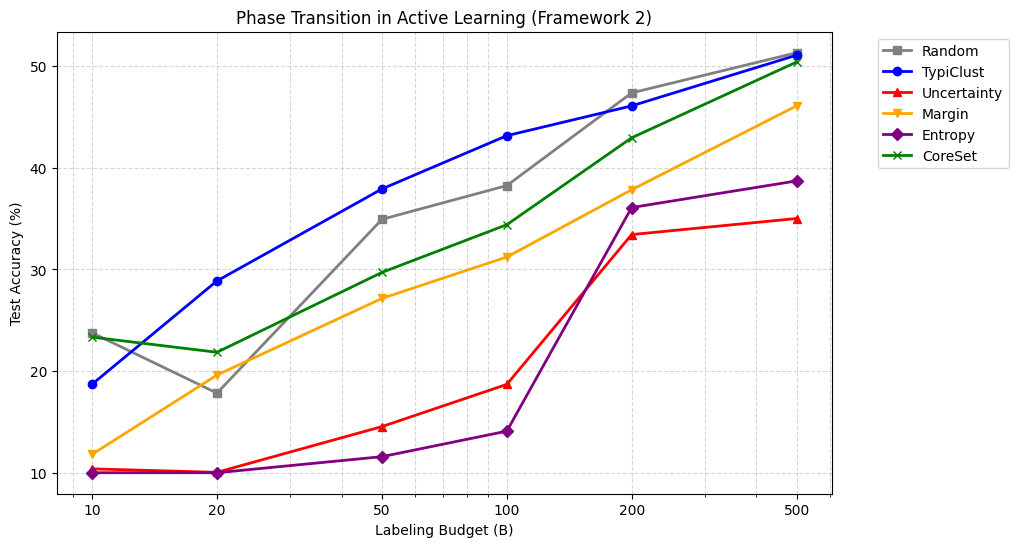

✅ Phase Transition Plot saved!


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Shrink the search pool to 5,000 images
pool_size = 5000
fast_pool_idx = np.random.choice(len(train_labels), size=pool_size, replace=False)
fast_embeddings = embeddings[fast_pool_idx]
fast_labels = train_labels[fast_pool_idx]
fast_all_indices = np.arange(pool_size)

budgets_to_test = [10, 20, 50, 100, 200, 500]
strategies_to_plot = ['Random', 'TypiClust', 'Uncertainty', 'Margin', 'Entropy', 'CoreSet']
results_history = {strat: [] for strat in strategies_to_plot}

print("Running evaluation across multiple budgets")

for b in budgets_to_test:
    print(f"Evaluating Budget = {b}...")

    # Run tools
    cluster_assigns = cluster_data(fast_embeddings, num_clusters=b)
    tc_idx = typiclust_select(fast_embeddings, cluster_assigns, budget=b)
    rand_idx = np.random.choice(pool_size, size=b, replace=False)
    unc_idx, mar_idx, ent_idx = get_confidence_baselines(fast_embeddings, fast_labels, fast_all_indices, budget=b)
    core_idx = coreset_select(fast_embeddings, budget=b)

    subsets = {
        'Random': rand_idx, 'TypiClust': tc_idx, 'Uncertainty': unc_idx,
        'Margin': mar_idx, 'Entropy': ent_idx, 'CoreSet': core_idx
    }

    for strat in strategies_to_plot:
        X_train, y_train = fast_embeddings[subsets[strat]], fast_labels[subsets[strat]]
        clf = LogisticRegression(max_iter=1000, C=1.0)
        try:
            clf.fit(X_train, y_train)
            acc = clf.score(test_embeddings, test_labels) * 100
        except ValueError:
            acc = 0.0
        results_history[strat].append(acc)

# Plotting
plt.figure(figsize=(10, 6))
colors = {'Random': 'gray', 'TypiClust': 'blue', 'Uncertainty': 'red', 'Margin': 'orange', 'Entropy': 'purple', 'CoreSet': 'green'}
markers = {'Random': 's', 'TypiClust': 'o', 'Uncertainty': '^', 'Margin': 'v', 'Entropy': 'D', 'CoreSet': 'x'}

for strat in strategies_to_plot:
    plt.plot(budgets_to_test, results_history[strat], label=strat, color=colors[strat], marker=markers[strat], linewidth=2)

plt.xscale('log')
plt.xticks(budgets_to_test, budgets_to_test)
plt.xlabel('Labeling Budget (B)')
plt.ylabel('Test Accuracy (%)')
plt.title('Phase Transition in Active Learning (Framework 2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig('phase_transition_plot_all6.png', dpi=300, bbox_inches='tight')
plt.show()

print("Phase Transition Plot saved!")